Buildings with res_subclass: 489
res_subclass values: ['MFH-AB', 'SBD', 'SFH-DB', 'TB']


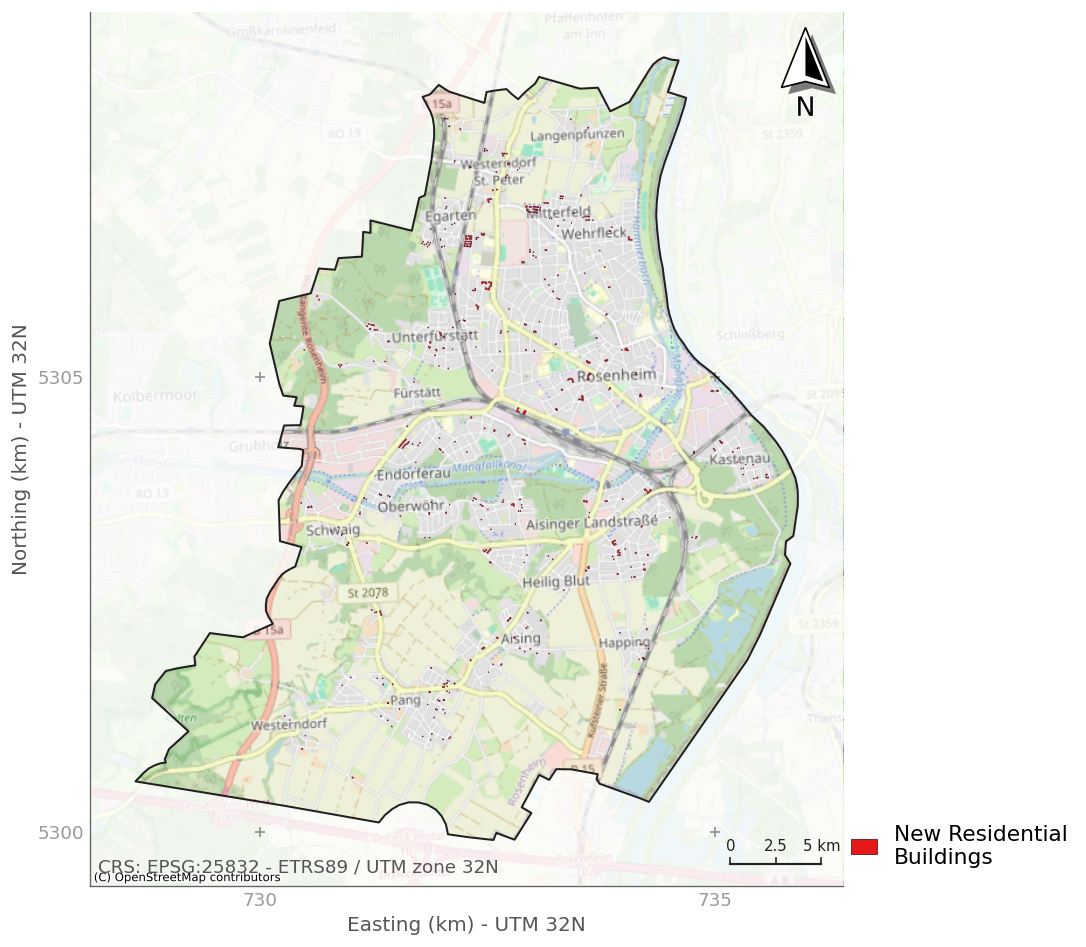

Saved map: C:\Users\agz90fk\Documents\Masterarbeit\06_Abbildungen\limitation_rosenheim_lod2_new.jpg


In [20]:
"""
LoD2 buildings in Rosenheim with res_subclass classification.
Template style with grid, north arrow, scale bar, and legend.
"""

import math
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from shapely.geometry import box

try:
    import contextily as ctx
    HAS_CTX = True
except Exception:
    HAS_CTX = False

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 19,
    "axes.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

# ---------------------------------------------------------------------------
# Paths and config
# ---------------------------------------------------------------------------
PATH_DISTRICT = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Limitation_Rosenheim\district_rosenheim.gpkg"
LAYER_DISTRICT = "de_vg250__v_vg250_krs"
PATH_LOD2_NEW  = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Limitation_Rosenheim\LoD2_2025_new_RO.gpkg"
OUTPUT_DIR     = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\06_Abbildungen")
OUTPUT_MAP     = OUTPUT_DIR / "limitation_rosenheim_lod2_new.jpg"

TARGET_CRS   = "EPSG:25832"
CRS_NOTE     = "CRS: EPSG:25832 - ETRS89 / UTM zone 32N"
GRID_STEP_M  = 5000
MAP_PADDING_M = 500
OSM_ZOOM     = 13

BUILDING_COLOR = "#e61919"
BUILDING_EDGE  = "#611926"


def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end   = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end   = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(round(x / 1000))}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(round(y / 1000))}"))

    if x_major and y_major:
        x_pts, y_pts = [], []
        for xv in x_major:
            for yv in y_major:
                x_pts.append(xv)
                y_pts.append(yv)
        ax.scatter(x_pts, y_pts, marker="+", s=30, linewidths=1.0, color="#8a8a8a", alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis="both", which="major", labelsize=11, length=0, colors="#9B9999")


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(
            ax=ax,
            location="upper right",
            size="md",
            rotation={"degrees": 0},
            aob={
                "bbox_to_anchor": (0.985, 0.985),
                "bbox_transform": ax.transAxes,
                "pad": 0.06,
                "borderpad": 0.06,
                "facecolor": "none",
                "edgecolor": "none",
                "alpha": 1.0,
                "frameon": False,
            },
        )
        return

    ax.annotate(
        "",
        xy=(0.945, 0.960),
        xytext=(0.945, 0.880),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-|>", color="#222222", linewidth=1.4, shrinkA=0, shrinkB=0),
        zorder=10,
    )
    ax.text(0.945, 0.972, "N", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=14, fontweight="bold", color="#222222", zorder=10)


def add_scale_bar(ax):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x = x1 - x0
    span_y = y1 - y0

    total_m   = 1000
    segment_m = 500

    x_start = x1 - span_x * 0.15
    y_start = y0 + span_y * 0.025

    ax.plot([x_start, x_start + total_m], [y_start, y_start], color="#222222", linewidth=1.3, zorder=8)
    tick_h = span_y * 0.006
    for xv in [x_start, x_start + segment_m, x_start + total_m]:
        ax.plot([xv, xv], [y_start, y_start + tick_h], color="#222222", linewidth=1.0, zorder=8)

    txt_y = y_start + span_y * 0.011
    ax.text(x_start,             txt_y, "0",     ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + segment_m, txt_y, "2.5",   ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + total_m,   txt_y, "5 km",  ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor("#f1f1f1")
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)

    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)

    ax.set_xlabel("Easting (km) - UTM 32N", fontsize=12, color="#555555")
    ax.set_ylabel("Northing (km) - UTM 32N", fontsize=12, color="#555555")
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes, ha="left", va="bottom", fontsize=11, color="#555555")

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#636262")
        ax.spines[side].set_linewidth(0.8)


# ---------------------------------------------------------------------------
# Load Rosenheim district boundary
# ---------------------------------------------------------------------------
gdf_district = gpd.read_file(PATH_DISTRICT, layer=LAYER_DISTRICT)
if gdf_district.crs is None or str(gdf_district.crs) != TARGET_CRS:
    gdf_district = gdf_district.to_crs(TARGET_CRS)
gdf_boundary = gdf_district[["geometry"]].dissolve().reset_index(drop=True)

# ---------------------------------------------------------------------------
# Load LoD2 buildings – keep only those with res_subclass not NULL
# ---------------------------------------------------------------------------
gdf_lod2 = gpd.read_file(PATH_LOD2_NEW)
if gdf_lod2.crs is None:
    raise ValueError("LoD2 dataset has no CRS.")
if gdf_lod2.crs != gdf_boundary.crs:
    gdf_lod2 = gdf_lod2.to_crs(gdf_boundary.crs)

gdf_lod2 = gdf_lod2[gdf_lod2["res_subclass"].notna()].copy()
print(f"Buildings with res_subclass: {len(gdf_lod2)}")
print(f"res_subclass values: {sorted(gdf_lod2['res_subclass'].unique())}")

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 9.4))
fig.subplots_adjust(right=0.80, left=0.07, top=0.92, bottom=0.08)

minx, miny, maxx, maxy = gdf_boundary.total_bounds
bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

if HAS_CTX:
    ctx.add_basemap(
        ax,
        crs=TARGET_CRS,
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom=OSM_ZOOM,
        attribution_size=7,
        alpha=0.8,
        reset_extent=False,
        zorder=1,
    )
else:
    print("contextily not installed: plotting without OSM basemap.")

# Dim OSM outside Rosenheim district
frame_poly   = box(bounds[0], bounds[1], bounds[2], bounds[3])
outside_geom = frame_poly.difference(gdf_boundary.geometry.iloc[0])
gpd.GeoDataFrame(geometry=[outside_geom], crs=TARGET_CRS).plot(
    ax=ax, facecolor="white", edgecolor="none", alpha=0.8, zorder=2,
)

# District boundary
gdf_boundary.plot(ax=ax, facecolor="none", edgecolor="#1f1f1f", linewidth=1.2, zorder=5)

# LoD2 buildings as polygons
gdf_lod2.plot(
    ax=ax,
    facecolor=BUILDING_COLOR,
    edgecolor=BUILDING_EDGE,
    linewidth=0.3,
    alpha=1,
    zorder=6,
)

add_north_arrow(ax)
add_scientific_frame(ax, gdf_boundary)
add_scale_bar(ax)

# Legend
handle = Patch(facecolor=BUILDING_COLOR, edgecolor=BUILDING_EDGE, linewidth=0.5,
               label="New Residential \nBuildings")
ax.legend(
    handles=[handle],
    loc="lower left",
    bbox_to_anchor=(1.01, 0.02),
    borderaxespad=0.0,
    frameon=False,
    fontsize=13,
    handlelength=1.2,
    labelspacing=0.6,
    borderpad=0.0,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_MAP, bbox_inches="tight", facecolor="white", format="jpg")
plt.show()

print(f"Saved map: {OUTPUT_MAP}")
